In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,precision_recall_fscore_support, roc_auc_score,average_precision_score,confusion_matrix,
                             RocCurveDisplay,PrecisionRecallDisplay,classification_report)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC


In [2]:
# Want to make sure Class field has either 1 (fraudulent transaction), 0 (Valid Transaction)
df = pd.read_csv('creditcard.csv')
df.head()
df['Class'].value_counts()
# In this data 492 transactions are fraud

,count
Class,
0,284315
1,492


In [3]:
## Creditcard dataset file from Kaggle
DATA_PATH='creditcard.csv'
TARGET='Class'
RANDOM_STATE=42


In [4]:
# Find the details of the dataset
df=pd.read_csv(DATA_PATH)
print("Shape:",df.shape)
print("Columns:",df.columns.tolist())
print("Missing % (top 10):\n",df.isna().mean().sort_values(ascending=False).head(10))
print("Describe:",df.describe(include='all').T.head(15))


Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Missing % (top 10):
 Time    0.0
V1      0.0
V2      0.0
V3      0.0
V4      0.0
V5      0.0
V6      0.0
V7      0.0
V8      0.0
V9      0.0
dtype: float64
Describe:          count          mean           std         min           25%  \
Time  284807.0  9.481386e+04  47488.145955    0.000000  54201.500000   
V1    284807.0  1.168375e-15      1.958696  -56.407510     -0.920373   
V2    284807.0  3.416908e-16      1.651309  -72.715728     -0.598550   
V3    284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365   
V4    284807.0  2.074095e-15      1.415869   -5.683171     -0.848640   
V5    284807.0  9.604066e-16      1.380247 -113.743307     -0.691597   
V6    284807.0  1.487313e-15      1.332271  -26.160506     -0.768296   
V7    284807.0

In [5]:
## Find the fraud rate from the dataset
fraud_rate=df[TARGET].mean()
print(f"Fraud prevalence: {fraud_rate:.4%}")


Fraud prevalence: 0.1727%


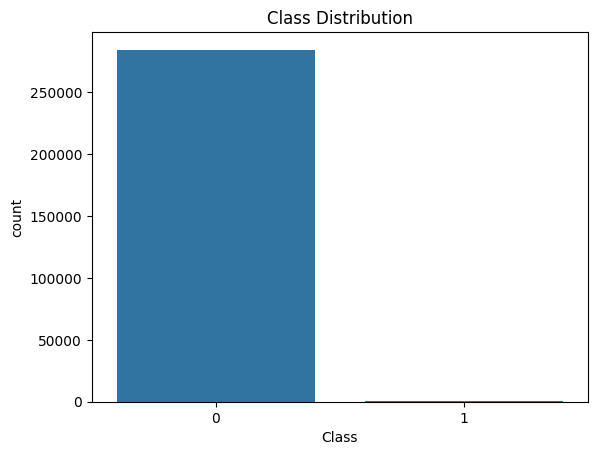

In [6]:
## Distribution of Target field which is Class in this case
sns.countplot(x=TARGET,data=df)
plt.title('Class Distribution')
plt.show()

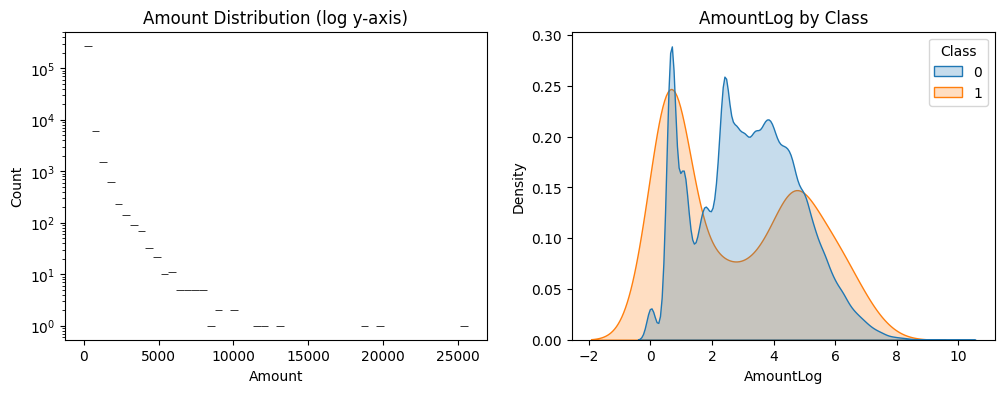

In [7]:
## Feature Engineering Plan
## EDA - Distributions
## We inspect Amount on Linear and log scales, then compare by class
## AmountLog: Log1p transform to reduce skew and spread small values

if "Amount" in df.columns:
  fig,ax=plt.subplots(1,2,figsize=(12,4))
  sns.histplot(df["Amount"],bins=50,ax=ax[0],log_scale=(False,True))
  ax[0].set_title("Amount Distribution (log y-axis)")
  df["AmountLog"]=np.log1p(df["Amount"])
  sns.kdeplot(data=df,x="AmountLog",hue=TARGET,common_norm=False,fill=True,ax=ax[1])
  ax[1].set_title("AmountLog by Class")
  plt.show()

In [8]:
# Data Cleaning
df=df.drop_duplicates()
num_cols=df.select_dtypes(include=np.number).columns.tolist()
df[num_cols]=df[num_cols].fillna(df[num_cols].median())

In [9]:
if "Amount" in df.columns and "AmountLog" not in df.columns:
  df["AmountLog"]=np.log1p(df["Amount"])


In [10]:
if "Time" in df.columns:
  hour=(df["Time"] % (24*3600)) /3600.0
  df["Time_sin"]=np.sin(2*np.pi*hour/24)
  df["Time_cos"]=np.cos(2*np.pi*hour/24)


In [11]:
X=df.drop(columns=[TARGET])
y=df[TARGET].astype(int)

In [12]:
## Train/test split (stratified due to strong class imbalance)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25, random_state=RANDOM_STATE,stratify=y)
num_features=X.columns.tolist()

In [13]:
scaler=StandardScaler()

In [ ]:
majority_class=y_train.mode()[0]
y_pred_majority=np.full_like(y_test, fill_value=majority_class)
baseline_accuracy=(y_test==y_pred_majority).mean()
baseline_pr_auc=y_test.mean()
print(f"Baseline (majority class) Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline PR AUC (prevalence): {baseline_pr_auc:.4f}")


Baseline (majority class) Accuracy: 0.9979
Baseline PR AUC (prevalence): 0.0021


/tmp/ipykernel_258/1216791536.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fr_by_decile.index,y=fr_by_decile.values,palette='viridis')


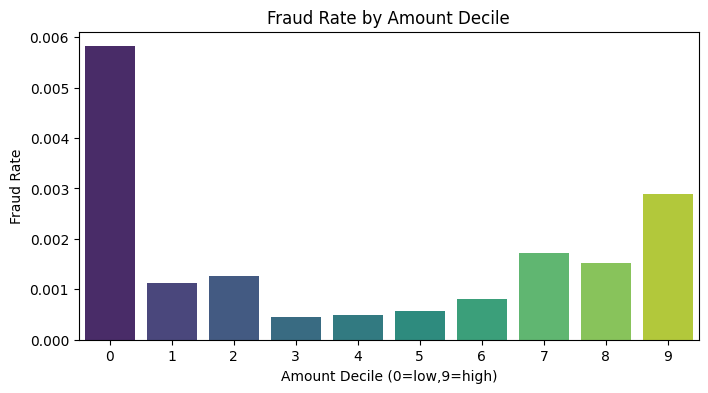

In [14]:
## EDA - Fraud rate by Amount and Time
if "Amount" in df.columns:
  tmp=df.copy()
  tmp['Amount_decile']=pd.qcut(tmp['Amount'].rank(method='first'),q=10,labels=False)
  fr_by_decile=tmp.groupby('Amount_decile')[TARGET].mean()
  plt.figure(figsize=(8,4))
  sns.barplot(x=fr_by_decile.index,y=fr_by_decile.values,palette='viridis')
  plt.title('Fraud Rate by Amount Decile')
  plt.xlabel('Amount Decile (0=low,9=high)')
  plt.ylabel('Fraud Rate')
  plt.show()

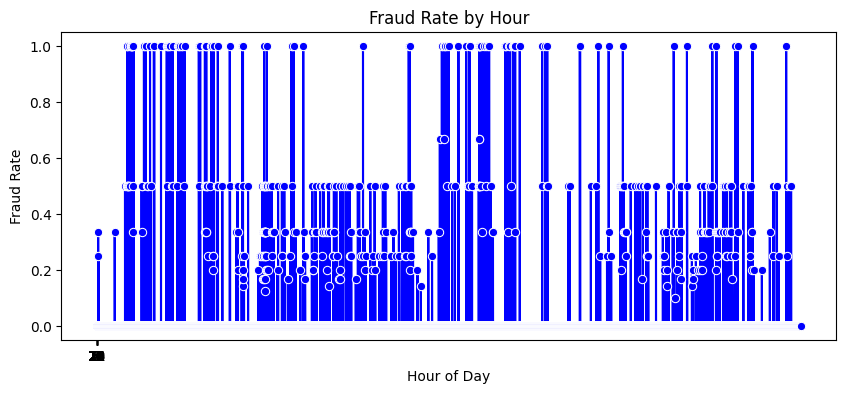

In [18]:
if 'Time' in df.columns:
  fr_by_hour=df.groupby('Time')[TARGET].mean()
  plt.figure(figsize=(10,4))
  sns.lineplot(x=fr_by_hour.index,y=fr_by_hour.values,marker='o',color='blue')
  plt.title('Fraud Rate by Hour')
  plt.xlabel('Hour of Day')
  plt.ylabel('Fraud Rate')
  plt.xticks(range(0,24))
  plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


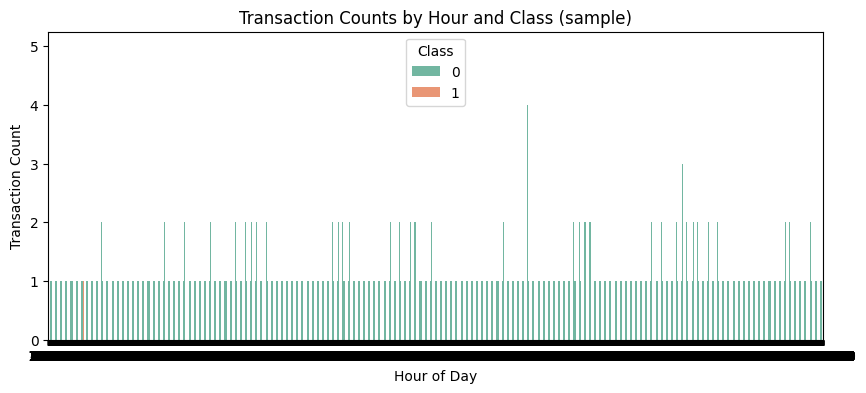

In [19]:
# Transaction counts by hour and class (Sample for clarity)
sample=df.sample(min(50000,len(df)),random_state=RANDOM_STATE)
plt.figure(figsize=(10,4))
sns.countplot(data=sample,x='Time',hue='Class',palette='Set2')
plt.title('Transaction Counts by Hour and Class (sample)')
plt.xlabel('Hour of Day')
plt.ylabel('Transaction Count')
plt.show()

/tmp/ipykernel_258/2361727078.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topn.values,y=topn.index,palette='mako')


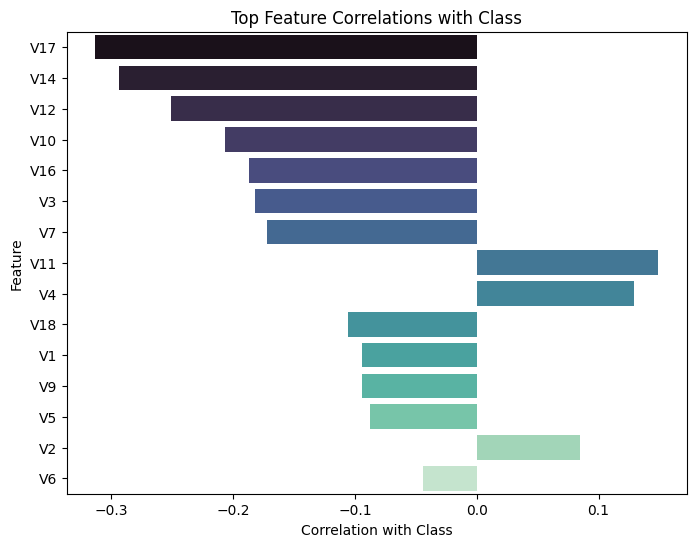

In [21]:
from numpy._core import numeric
## EDA - Corelation views
numeric_cols=[c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c!=TARGET]
corr_with_y=df[numeric_cols].corrwith(df[TARGET]).sort_values(key=lambda s:s.abs(),ascending=False)
topn=corr_with_y.head(15)
plt.figure(figsize=(8,6))
sns.barplot(x=topn.values,y=topn.index,palette='mako')
plt.title('Top Feature Correlations with Class')
plt.xlabel('Correlation with Class')
plt.ylabel('Feature')
plt.show()

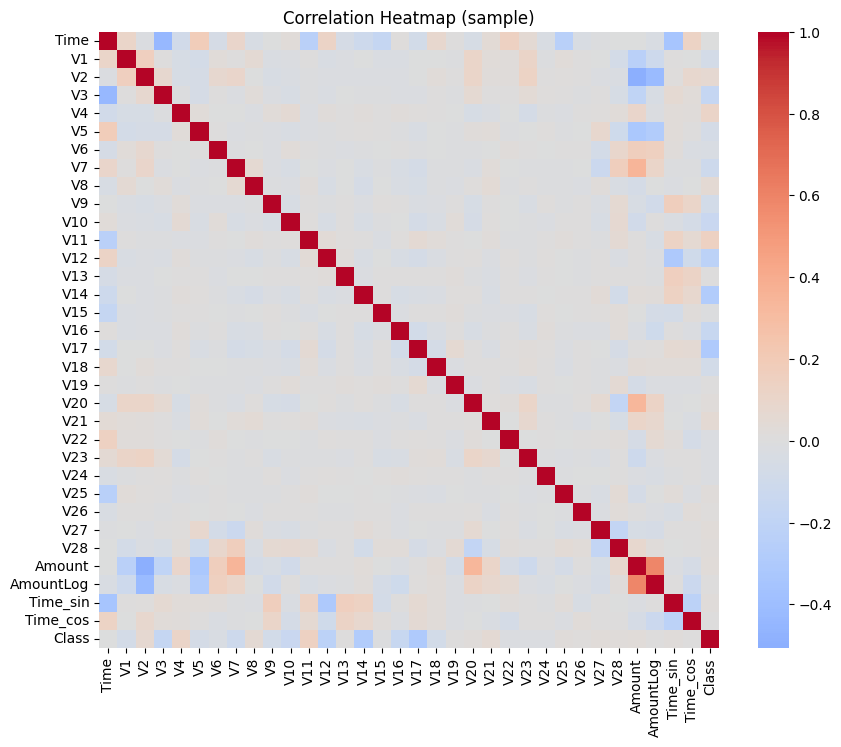

In [24]:
## Heatmap on a sample for readability
sample_size=min(10000,len(df))
corr_sample=df.sample(sample_size,random_state=RANDOM_STATE)
corr_matrix=corr_sample[numeric_cols+['Class']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,cmap='coolwarm',center=0,cbar=True)
plt.title('Correlation Heatmap (sample)')
plt.show()

In [30]:
## Used 4 models that we learned for comparion

models = {
    'Logistic Regression': Pipeline([('scale',scaler),('clf',LogisticRegression(max_iter=2000,class_weight='balanced'))]),
    'KNN': Pipeline([('scale',scaler),('clf',KNeighborsClassifier())]),
    'Decision Tree': Pipeline([('scale',scaler),('clf',DecisionTreeClassifier(random_state=RANDOM_STATE,class_weight='balanced'))]),
    'SVM': Pipeline([('scale',scaler),('clf',SVC(kernel='rbf',probability=True,class_weight='balanced'))])
}

In [31]:
def evaluate(name,model, X_train, y_train, X_test, y_test):
  t0=time.time()
  model.fit(X_train, y_train)
  fit_time=time.time()-t0
  y_tr_pred=model.predict(X_train)
  y_te_pred=model.predict(X_test)



In [32]:
def evaluate(name,model, X_train, y_train, X_test, y_test):
  t0=time.time()
  model.fit(X_train, y_train)
  fit_time=time.time()-t0
  y_tr_pred=model.predict(X_train)
  y_te_pred=model.predict(X_test)

  if hasattr(model, 'predict_proba'):
    y_scores=model.predict_proba(X_test)[:,1]
  else:
    last=model.named_steps.get('clf',model)
    if hasattr(last, 'predict_proba'):
      y_scores=last.predict_proba(model.named_steps['scale'].transform(X_test))[:,1]
    elif hasattr(last, 'decision_function'):
      y_scores=last.decision_function(model.named_steps['scale'].transform(X_test))
    else:
      y_scores=y_te_pred

  train_acc=accuracy_score(y_train, y_tr_pred)
  test_acc=accuracy_score(y_test, y_te_pred)
  prec,rec,f1,_=precision_recall_fscore_support(y_test, y_te_pred, average='binary')
  roc=roc_auc_score(y_test, y_scores) # Calculate ROC-AUC
  pr_auc=average_precision_score(y_test, y_scores) # Calculate PR AUC

  return {
      'Model': name,
      'Train Accuracy': round(train_acc,4),
      'Test Accuracy': round(test_acc,4),
      'Precision': round(prec,4),
      'Recall': round(rec,4),
      'F1 Score': round(f1,4),
      'ROC-AUC':round(roc,4),
      'PR-AUC': round(pr_auc,4),
      'Fit Time': round(fit_time,4)
  }, model

In [33]:
results=[]
fitted_models={}
for name, model in models.items():
  res,fitted=evaluate(name,model, X_train, y_train, X_test, y_test)
  results.append(res)
  fitted_models[name]=fitted
results_df=pd.DataFrame(results).sort_values(by=["PR-AUC","Recall"],ascending=False).reset_index(drop=True)
print(results_df)

                 Model  Train Accuracy  Test Accuracy  Precision  Recall  \
0                  KNN          0.9996         0.9994     0.9552  0.6737   
1  Logistic Regression          0.9766         0.9753     0.0565  0.8737   
2                  SVM          0.9992         0.9985     0.5372  0.6842   
3        Decision Tree          1.0000         0.9990     0.7126  0.6526   

   F1 Score  ROC-AUC  PR-AUC   Fit Time  
0    0.7901   0.8893  0.7566     0.2217  
1    0.1061   0.9695  0.6735     3.7500  
2    0.6019   0.9759  0.5743  1249.6944  
3    0.6813   0.8261  0.4657    15.9090  


In [34]:
best_name=results_df.loc[0,'Model']
best_model=fitted_models[best_name]
print("Best model by PR_AUC:",best_name)

Best model by PR_AUC: KNN


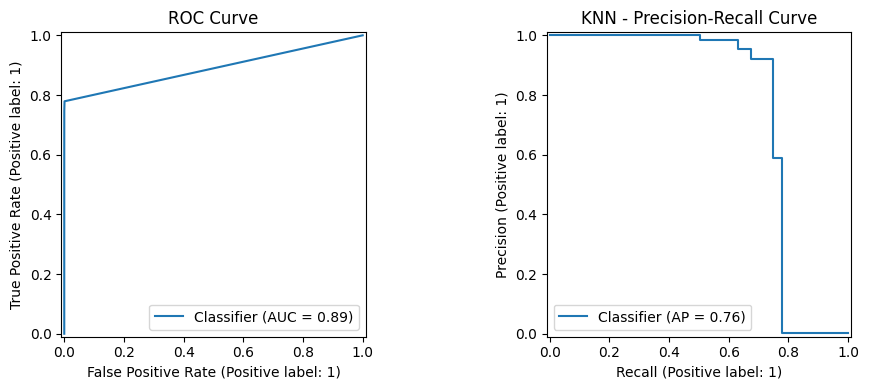

In [35]:
if hasattr(best_model, 'predict_proba'):
  y_score=best_model.predict_proba(X_test)[:,1]
else:
  y_score=best_model.decision_function(X_test)
fig,axes=plt.subplots(1,2,figsize=(10,4))
RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[0])
axes[0].set_title("ROC Curve")
PrecisionRecallDisplay.from_predictions(y_test, y_score,ax=axes[1])
axes[1].set_title(f"{best_name} - Precision-Recall Curve")
plt.tight_layout()
plt.show()

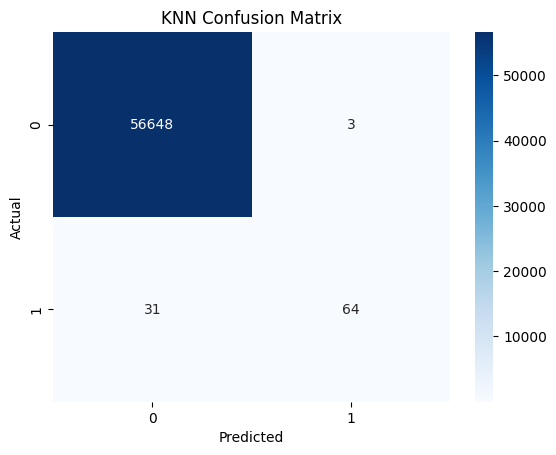

In [36]:
y_pred=best_model.predict(X_test)
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{best_name} Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [37]:
from sklearn.metrics import precision_recall_curve
# Example: Choose threshold to achieve at least 80% recall
if hasattr(best_model, 'predict_proba'):
  y_score=best_model.predict_proba(X_test)[:,1]
else:
  y_score=best_model.decision_function(X_test)
prec,rec,thr=precision_recall_curve(y_test, y_score)
target_recall=0.8
idx=np.where(rec>=target_recall)[0]
if len(idx)>0:
  t_star=thr[idx[0]] if idx[0]<len(thr) else 0.5
  print(f"Threshold for > {target_recall*100:.0f}% recall:",round(float(t_star),4))
  y_opt=(y_score>=t_star).astype(int)
  p_opt,r_opt,f1_opt,_=precision_recall_fscore_support(y_test, y_opt, average='binary',zero_division=0)
  print({"Precision": round(p_opt,4),"Recall": round(r_opt,4),"F1": round(f1_opt,4)})

Threshold for > 80% recall: 0.0
{'Precision': 0.0017, 'Recall': 1.0, 'F1': 0.0033}
